In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])


def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i


Fit using new data, where fl, b1, b2, cx, cy are from the data

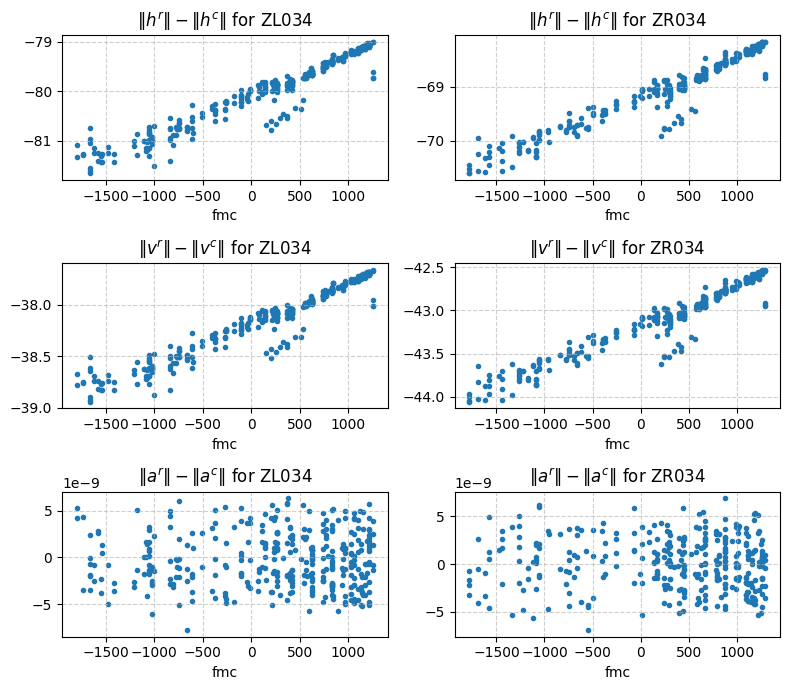

In [6]:
data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
zl, zr = get_zl_zr("034", data_all)
parse_cahvor(zl)
parse_cahvor(zr)

# here we plot norm(H^r) - norm(H^c) 
fig, ax = plt.subplots(3, 2, figsize=(8,7))

for j, data in enumerate([zl, zr]):
  diffs = []
  for i in range(data.shape[0]):
    fl, b1, b2, cx, cy = data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    
    Hr = get_H_r_data(i, data)
    Hr_norm_sq = np.linalg.norm(Hr, axis=0)
    Hc_norm_sq = np.linalg.norm(Hc, axis=0)
    diffs.append(Hr_norm_sq - Hc_norm_sq)

  for k in range(3):
    ax[k, j].scatter(data["fmc"], [diff[k] for diff in diffs], marker='.')
    ax[k, j].set_xlabel("fmc")
    ax[k, j].set_ylabel("")
    ax[k, j].grid(linestyle="--", alpha=0.6)
  
  cam_name = "ZL034" if j==0 else "ZR034"
  ax[0, j].set_title(f"$\|h^r\|-\|h^c\|$ for {cam_name}")
  ax[1, j].set_title(f"$\|v^r\|-\|v^c\|$ for {cam_name}")
  ax[2, j].set_title(f"$\|a^r\|-\|a^c\|$ for {cam_name}")
  
fig.tight_layout()

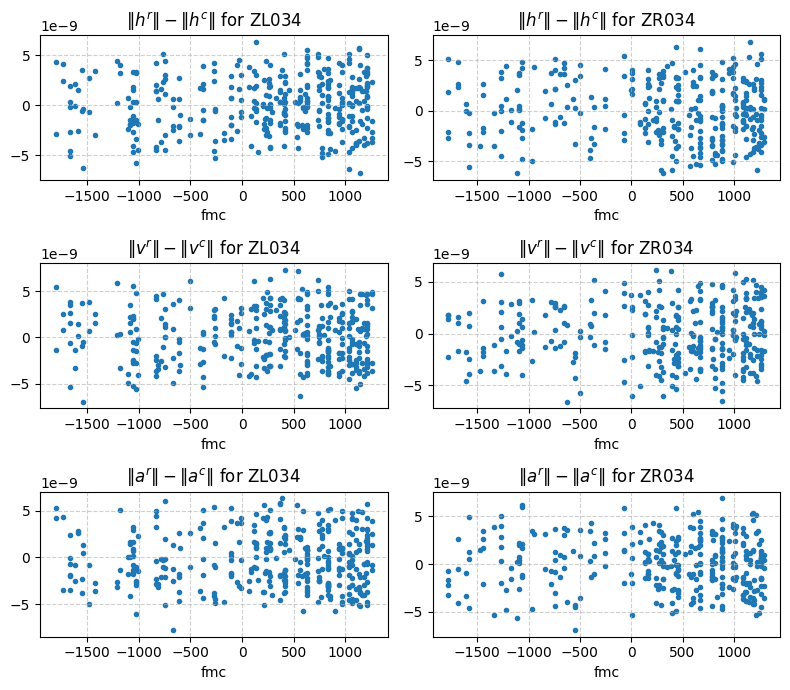

In [3]:
data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
zl, zr = get_zl_zr("034", data_all)
parse_cahvor(zl)
parse_cahvor(zr)

# here we plot norm(H^r) - norm(H^c) 
fig, ax = plt.subplots(3, 2, figsize=(8,7))

for j, data in enumerate([zl, zr]):
  diffs = []
  for i in range(data.shape[0]):
    fl, b1, b2, cx, cy = data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx-824, cy-600, 1]]
    Hr = get_H_r_data(i, data)
    Hr_norm = np.linalg.norm(Hr, axis=0)
    Hc_norm = np.linalg.norm(Hc, axis=0)
    diffs.append(Hr_norm - Hc_norm)

  for k in range(3):
    ax[k, j].scatter(data["fmc"], [diff[k] for diff in diffs], marker='.')
    ax[k, j].set_xlabel("fmc")
    ax[k, j].set_ylabel("")
    ax[k, j].grid(linestyle="--", alpha=0.6)
  
  cam_name = "ZL034" if j==0 else "ZR034"
  ax[0, j].set_title(f"$\|h^r\|-\|h^c\|$ for {cam_name}")
  ax[1, j].set_title(f"$\|v^r\|-\|v^c\|$ for {cam_name}")
  ax[2, j].set_title(f"$\|a^r\|-\|a^c\|$ for {cam_name}")
  
fig.tight_layout()

Fit using old data, where fl, b1, b2, cx, cy are from the data

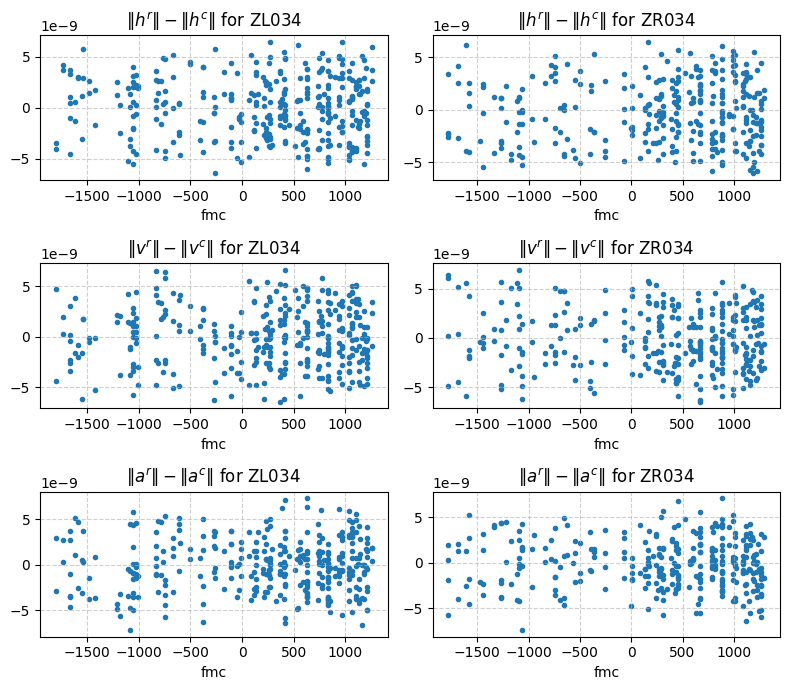

In [4]:
data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data_all = pd.read_excel(data_fpath)
zl, zr = get_zl_zr("034", data_all)
parse_cahvor(zl)
parse_cahvor(zr)

# here we plot norm(H^r) - norm(H^c) 
fig, ax = plt.subplots(3, 2, figsize=(8,7))

for j, data in enumerate([zl, zr]):
  diffs = []
  for i in range(data.shape[0]):
    fl, b1, b2, cx, cy = data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    Hr = get_H_r_data(i, data)
    Hr_norm = np.linalg.norm(Hr, axis=0)
    Hc_norm = np.linalg.norm(Hc, axis=0)
    diffs.append(Hr_norm - Hc_norm)

  for k in range(3):
    ax[k, j].scatter(data["fmc"], [diff[k] for diff in diffs], marker='.')
    ax[k, j].set_xlabel("fmc")
    ax[k, j].set_ylabel("")
    ax[k, j].grid(linestyle="--", alpha=0.6)
  
  cam_name = "ZL034" if j==0 else "ZR034"
  ax[0, j].set_title(f"$\|h^r\|-\|h^c\|$ for {cam_name}")
  ax[1, j].set_title(f"$\|v^r\|-\|v^c\|$ for {cam_name}")
  ax[2, j].set_title(f"$\|a^r\|-\|a^c\|$ for {cam_name}")
  
fig.tight_layout()

Fit using new data, where b1, b2, cx, cy are from the old data

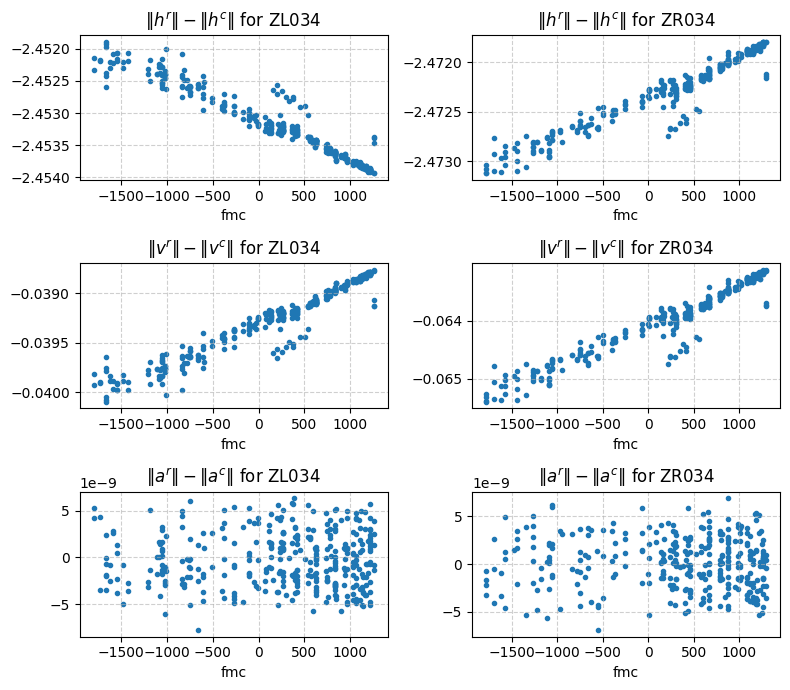

In [5]:
data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
zl, zr = get_zl_zr("034", data_all)
parse_cahvor(zl)
parse_cahvor(zr)

# here we plot norm(H^r) - norm(H^c) 
fig, ax = plt.subplots(3, 2, figsize=(8,7))

for j, data in enumerate([zl, zr]):
  diffs = []
  for i in range(data.shape[0]):
    fl = data["f_est"].iloc[i]
    b1 = -0.5296 if j == 0 else -0.92005
    b2 = -2.30 if j == 0 else 0.56388
    cx = 40.99626 if j == 0 else 23.9963
    cy = 19.2043 if j == 0 else 46.5629
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    Hr = get_H_r_data(i, data)
    Hr_norm = np.linalg.norm(Hr, axis=0)
    Hc_norm = np.linalg.norm(Hc, axis=0)
    diffs.append(Hr_norm - Hc_norm)

  for k in range(3):
    ax[k, j].scatter(data["fmc"], [diff[k] for diff in diffs], marker='.')
    ax[k, j].set_xlabel("fmc")
    ax[k, j].set_ylabel("")
    ax[k, j].grid(linestyle="--", alpha=0.6)
  
  cam_name = "ZL034" if j==0 else "ZR034"
  ax[0, j].set_title(f"$\|h^r\|-\|h^c\|$ for {cam_name}")
  ax[1, j].set_title(f"$\|v^r\|-\|v^c\|$ for {cam_name}")
  ax[2, j].set_title(f"$\|a^r\|-\|a^c\|$ for {cam_name}")
  
fig.tight_layout()